# D_S3.1 — Full-Case Classification Tree

Apply the classification tree from D_S3 to **all** cases (all SNR levels, all replicates),
and report per-family proportions at each step.

Tree: Global Relationship → Simple/Complex → Direction → Monotonicity → Line Detection → Curvature

In [893]:
# ── Imports and paths ──
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.0)
plt.rcParams['figure.dpi'] = 120

S1_DIR = Path('output/S1')
S2_DIR = Path('output/S2')

## Load Data

In [894]:
# ── Data selection settings ──
USE_STRONG   =     True
USE_STANDARD =  False
USE_MILD     =   False
EXCLUDE_INF_SNR = True    # exclude noise-free (SNR=∞) cases

cases = pd.read_csv(S1_DIR / 'cases.csv', low_memory=False)
metrics = pd.read_parquet(S2_DIR / 'metrics_full.parquet')

meta_cols = ['case_id', 'family_id', 'family_name', 'snr', 'spread_pattern',
             'x_distribution', 'category', 'direction', 'linearity',
             'monotonicity', 'special_shape', 'replicate', 'variant_level']
meta = cases[[c for c in meta_cols if c in cases.columns]].copy()

df = metrics.merge(meta, on='case_id', how='left')
df['snr_val'] = df['snr'].apply(lambda x: float('inf') if str(x) == 'inf' else float(x))

allowed_levels = []
if USE_STRONG:   allowed_levels.append('strong')
if USE_STANDARD: allowed_levels.append('standard')
if USE_MILD:     allowed_levels.append('mild')
allowed_levels.append('none')

df = df[df['variant_level'].isin(allowed_levels)].copy()

if EXCLUDE_INF_SNR:
    n_before = len(df)
    df = df[df['snr_val'] != float('inf')].copy()
    print(f'Excluded SNR=∞ cases: {n_before - len(df):,} removed')

signal = df[df['family_id'] != 'Null'].copy()
null_df = df[df['category'] == 'true_null'].copy()

SHORT = {
    'F01': 'Linear(+)',   'F02': 'Linear(-)',   'F03': 'PwrCvx(+)',
    'F04': 'PwrCvx(-)',   'F05': 'PwrCcv(+)',   'F06': 'PwrCcv(-)',
    'F07': 'Sat(+)',      'F08': 'Sat(-)',       'F09': 'Log(+)',
    'F10': 'Log(-)',      'F11': 'Exp(+)',       'F12': 'Exp(-)',
    'F13': 'S-crv(+)',    'F14': 'S-crv(-)',     'F15': 'Thresh(+)',
    'F16': 'Thresh(-)',   'F17': 'Peak',         'F18': 'Valley',
    'F19': 'Spike',       'F20': 'Inv Spike',    'F21': 'Cubic',
    'F22': 'Oscillation', 'F23': 'Two Lines',    'F24': 'L+Parab',
    'F25': 'Multi-reg',   'F26': 'Windowed J',   'Null': 'No relationship',
}

print(f'Variant levels: {allowed_levels}')
print(f'EXCLUDE_INF_SNR: {EXCLUDE_INF_SNR}')
print(f'Total: {len(df):,} cases')
print(f'Signal (26 families): {len(signal):,}')
print(f'Null: {len(null_df):,}')

Excluded SNR=∞ cases: 270 removed
Variant levels: ['strong', 'none']
EXCLUDE_INF_SNR: True
Total: 54,000 cases
Signal (26 families): 52,000
Null: 2,000


In [895]:
# ── Unified color palette ──
C_GLOBAL     = '#1976D2'
C_SIMPLE     = '#2E7D32'
C_COMPLEX    = '#EF6C00'
C_NO_REL     = '#BDBDBD'
C_NULL       = '#7E7E7E'
C_POS        = '#4FC3F7'
C_NEG        = '#EF5350'
C_MONO_S     = '#66BB6A'
C_MONO_M     = '#FFA726'
C_LINE       = '#26C6DA'
C_NONLINE    = '#6A1B9A'
C_CONVEX     = '#2E7D32'
C_CONCAVE    = '#00897B'
C_INFLECTED  = '#EF6C00'
C_WEAK       = '#757575'

In [896]:
# ── Helper: two-column family table ──
def print_family_table(data_df, fids, columns, header_fmt, row_fmt, majority_fn=None):
    """Print a two-column table of per-family counts."""
    hdr = header_fmt
    sep = '─' * len(hdr)
    rows = []
    for fid in fids:
        sub = data_df[data_df['family_id'] == fid]
        rows.append(row_fmt(fid, sub))

    mid = (len(rows) + 1) // 2
    col_w = len(hdr)
    print(f'{hdr:<{col_w}}  {hdr}')
    print(f'{sep}  {sep}')
    for i in range(mid):
        left = rows[i]
        right = rows[i + mid] if i + mid < len(rows) else ''
        print(f'{left:<{col_w}}  {right}')
    print()

def fmt_count_pct(count, total, width=5):
    """Return 'count(pct)' with a safe denominator."""
    if total == 0:
        return f'{count:>{width},}(  —)'
    return f'{count:>{width},}({count/total:>4.0%})'



## Step 1 — Global Relationship

`MIC >= 0.8 AND distance_correlation >= 0`

In [897]:
# ── Step 1: Global Relationship ──
MIC_THRESH = 0.8
DCOR_THRESH = 0

mic_pass  = signal['MIC'] >= MIC_THRESH
dcor_pass = signal['distance_correlation'] >= DCOR_THRESH
both_pass = mic_pass & dcor_pass

filtered_cases = signal[both_pass].copy()

all_fids = sorted(signal['family_id'].unique())
qual_fids = sorted(filtered_cases['family_id'].unique())
excl_fids = [f for f in all_fids if f not in qual_fids]

print(f'═══ Step 1: Global Relationship ═══')
print(f'Rule: MIC ≥ {MIC_THRESH} AND dcor ≥ {DCOR_THRESH}  (per case)')
print()
print(f'  MIC ≥ {MIC_THRESH}:  {mic_pass.sum():>7,} / {len(signal):,}  ({mic_pass.mean():.1%})')
print(f'  dcor ≥ {DCOR_THRESH}: {dcor_pass.sum():>7,} / {len(signal):,}  ({dcor_pass.mean():.1%})')
print(f'  Both:     {both_pass.sum():>7,} / {len(signal):,}  ({both_pass.mean():.1%})')
print(f'  Qualifying families: {len(qual_fids)} / {len(all_fids)}  ({len(qual_fids)/len(all_fids):.1%}) — {qual_fids}')
print(f'  Excluded: {excl_fids}')
print()

hdr = f'{"Family":<16} {"MIC≥.8":>12} {"dcor≥0":>12} {"Both":>12} {"Total":>7}'
def _row_s1(fid, sub):
    n = len(sub)
    n_mic  = int((sub['MIC'] >= MIC_THRESH).sum())
    n_dcor = int((sub['distance_correlation'] >= DCOR_THRESH).sum())
    n_both = int(((sub['MIC'] >= MIC_THRESH) & (sub['distance_correlation'] >= DCOR_THRESH)).sum())
    return f'{fid} {SHORT[fid]:<10} {n_mic:>5,}({n_mic/n:>4.0%}) {n_dcor:>5,}({n_dcor/n:>4.0%}) {n_both:>5,}({n_both/n:>4.0%}) {n:>7,}'

print_family_table(signal, all_fids, None, hdr, _row_s1)


═══ Step 1: Global Relationship ═══
Rule: MIC ≥ 0.8 AND dcor ≥ 0  (per case)

  MIC ≥ 0.8:   11,629 / 52,000  (22.4%)
  dcor ≥ 0:  52,000 / 52,000  (100.0%)
  Both:      11,629 / 52,000  (22.4%)
  Qualifying families: 21 / 26  (80.8%) — ['F01', 'F02', 'F03', 'F04', 'F05', 'F06', 'F07', 'F08', 'F09', 'F10', 'F11', 'F12', 'F13', 'F14', 'F15', 'F16', 'F17', 'F18', 'F21', 'F22', 'F23']
  Excluded: ['F19', 'F20', 'F24', 'F25', 'F26']

Family                 MIC≥.8       dcor≥0         Both   Total  Family                 MIC≥.8       dcor≥0         Both   Total
───────────────────────────────────────────────────────────────  ───────────────────────────────────────────────────────────────
F01 Linear(+)    707( 35%) 2,000(100%)   707( 35%)   2,000       F14 S-crv(-)     815( 41%) 2,000(100%)   815( 41%)   2,000
F02 Linear(-)    707( 35%) 2,000(100%)   707( 35%)   2,000       F15 Thresh(+)    843( 42%) 2,000(100%)   843( 42%)   2,000
F03 PwrCvx(+)    520( 26%) 2,000(100%)   520( 26%)   2,000  

F25 Multi-reg: 0/2000 passed Step 1 — skipped
F26 Windowed J: 0/2000 passed Step 1 — skipped


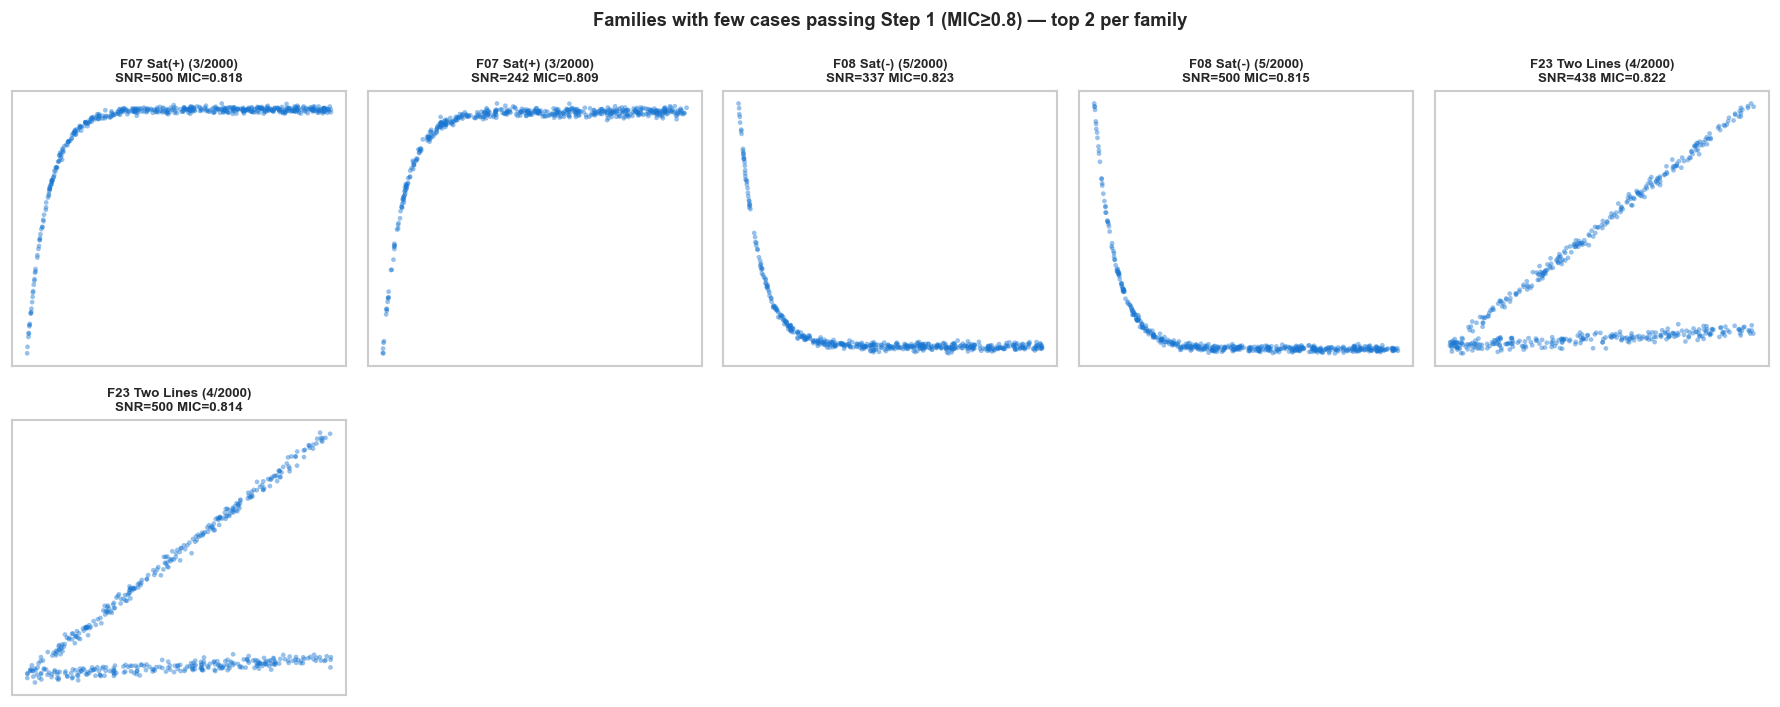

In [898]:
# ── Step 1 补充: 被排除家族的散点图 (有 global relationship 的 cases) ──
# F07/F08 Saturation, F23 Two Lines, F25 Multi-reg, F26 Windowed J
# 这些家族大部分 case 的 MIC < 0.8，但仍有少量通过了 Step 1

EXCL_SHOW = ['F07', 'F08', 'F23', 'F25', 'F26']
N_SHOW_PER_FAMILY = 2

pts = np.load(S1_DIR / 'scatter_points.npz')
x_all, y_all = pts['x'], pts['y']

cases_full = pd.read_csv(S1_DIR / 'cases.csv', low_memory=False)
case_idx_by_id = pd.Series(np.arange(len(cases_full)), index=cases_full['case_id']).to_dict()

show_rows = []
for fid in EXCL_SHOW:
    fid_pass = filtered_cases[filtered_cases['family_id'] == fid] if fid in qual_fids else pd.DataFrame()
    n_total = len(signal[signal['family_id'] == fid])
    n_pass = len(fid_pass)
    if n_pass == 0:
        print(f'{fid} {SHORT[fid]}: 0/{n_total} passed Step 1 — skipped')
        continue
    top = fid_pass.sort_values('MIC', ascending=False).head(N_SHOW_PER_FAMILY)
    for _, row in top.iterrows():
        show_rows.append((fid, n_pass, n_total, row))

if show_rows:
    ncols = min(len(show_rows), 5)
    nrows = math.ceil(len(show_rows) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.0 * ncols, 3.0 * nrows), squeeze=False)

    fig.suptitle(f'Families with few cases passing Step 1 (MIC≥{MIC_THRESH}) — top {N_SHOW_PER_FAMILY} per family',
                 fontsize=11, fontweight='bold')

    for j, (fid, n_pass, n_total, row) in enumerate(show_rows):
        ax = axes[j // ncols, j % ncols]
        idx = case_idx_by_id.get(row['case_id'])
        if idx is not None:
            ax.scatter(x_all[idx], y_all[idx], s=8, alpha=0.45,
                       color='#1976D2', edgecolors='none')
        snr_str = f'{row["snr_val"]:.0f}' if np.isfinite(row['snr_val']) else '∞'
        ax.set_title(
            f'{fid} {SHORT[fid]} ({n_pass}/{n_total})\n'
            f'SNR={snr_str} MIC={row["MIC"]:.3f}',
            fontsize=8, fontweight='bold')
        ax.set_xticks([]); ax.set_yticks([])

    for j in range(len(show_rows), nrows * ncols):
        axes[j // ncols, j % ncols].set_visible(False)

    plt.tight_layout()
    plt.show()

## Step 2 — Simple vs Complex

Base: `|ρ| ≥ 0.7 AND |r| ≥ 0.7`
Optional gates (toggleable):
- `MAS < 0.10` — non-monotonicity filter
- `MIC-r² < 0.20` — non-linearity filter (catches threshold-type)
- **Slope sign-change gate** — bin raw scatter data into N bins, compute slope per bin, count adjacent sign changes. Cases with any sign change (turning point) → Complex.
  - `N_SLOPE_BINS`: number of bins (default 5)
  - `BIN_MODE`: `equal_count` (quantile) or `equal_width`
  - `MAX_SIGN_CHANGES`: max allowed sign changes (default 0 = strict, no turning point)
  - `USE_PROMINENCE_FILTER`: toggle prominence filtering on/off
  - `MIN_REVERSAL_PROMINENCE`: minimum `|slope_right| / |slope_left|` for a sign change to count (default 0.1). Compares with left neighbor — filters out noise-induced near-zero slope flips.

In [899]:
# ── Step 2: Simple vs Complex ──
R_THRESH = 0.7

USE_REV_GATE = False
REVERSAL_PROMINENCE = 0.10

USE_MAS_GATE = False
MAS_THRESH = 0.20

USE_MR_GATE = False
MR_THRESH = 0.20

USE_SIGN_CHANGE_GATE = True
MAX_SIGN_CHANGES = 1         # 0 = strict (no turning point allowed)
N_SLOPE_BINS = 3              # number of bins for slope computation
BIN_MODE = 'equal_count'      # 'equal_count' (quantile) or 'equal_width'
USE_PROMINENCE_FILTER = True  # filter out noise sign changes by neighbor ratio
MIN_REVERSAL_PROMINENCE = 0.1 # |slope_right| / |slope_left| must exceed this

sc = filtered_cases.copy()

cond_rho = sc['spearman_rho'].abs() >= R_THRESH
cond_r   = sc['pearson_r'].abs() >= R_THRESH
cond_mas = sc['MAS'] < MAS_THRESH if USE_MAS_GATE else True
cond_mr  = sc['MIC_minus_r2'] < MR_THRESH if USE_MR_GATE else True

# ── Binned slope sign-change detection (from raw scatter data) ──
if USE_SIGN_CHANGE_GATE:
    _pts = np.load(S1_DIR / 'scatter_points.npz')
    _x_raw, _y_raw = _pts['x'], _pts['y']
    _cidx = pd.Series(np.arange(len(cases)), index=cases['case_id']).to_dict()
    _idx = np.array([_cidx[cid] for cid in sc['case_id'].values])
    _x = _x_raw[_idx]  # (n_cases, 500)
    _y = _y_raw[_idx]

    # Sort by x within each case
    _srt = np.argsort(_x, axis=1)
    _xs = np.take_along_axis(_x, _srt, axis=1)
    _ys = np.take_along_axis(_y, _srt, axis=1)
    n_pts = _xs.shape[1]

    bin_slopes = np.zeros((len(sc), N_SLOPE_BINS))

    if BIN_MODE == 'equal_count':
        edges = np.linspace(0, n_pts, N_SLOPE_BINS + 1, dtype=int)
        for b in range(N_SLOPE_BINS):
            xb = _xs[:, edges[b]:edges[b+1]]
            yb = _ys[:, edges[b]:edges[b+1]]
            nb = edges[b+1] - edges[b]
            sx  = xb.sum(axis=1)
            sy  = yb.sum(axis=1)
            sxy = (xb * yb).sum(axis=1)
            sx2 = (xb ** 2).sum(axis=1)
            denom = nb * sx2 - sx ** 2
            denom = np.where(denom == 0, 1, denom)
            bin_slopes[:, b] = (nb * sxy - sx * sy) / denom
    else:  # equal_width
        _xmin = _xs[:, [0]]
        _xrng = _xs[:, [-1]] - _xmin
        _xrng = np.where(_xrng == 0, 1, _xrng)
        _xn = (_xs - _xmin) / _xrng
        for b in range(N_SLOPE_BINS):
            lo = b / N_SLOPE_BINS
            hi = (b + 1) / N_SLOPE_BINS
            mask = (_xn >= lo) & (_xn < hi) if b < N_SLOPE_BINS - 1 else (_xn >= lo)
            nb  = mask.sum(axis=1).astype(float)
            sx  = np.where(mask, _xs, 0).sum(axis=1)
            sy  = np.where(mask, _ys, 0).sum(axis=1)
            sxy = np.where(mask, _xs * _ys, 0).sum(axis=1)
            sx2 = np.where(mask, _xs ** 2, 0).sum(axis=1)
            denom = nb * sx2 - sx ** 2
            valid = (nb >= 2) & (denom != 0)
            denom = np.where(valid, denom, 1)
            bin_slopes[:, b] = np.where(valid, (nb * sxy - sx * sy) / denom, 0)

    # Count adjacent sign changes
    signs = np.sign(bin_slopes)  # (n_cases, N_SLOPE_BINS)
    sign_diffs = np.diff(signs, axis=1)  # non-zero where sign changes
    has_change = sign_diffs != 0  # (n_cases, N_SLOPE_BINS-1)

    # Prominence filter: compare with left neighbor
    if USE_PROMINENCE_FILTER:
        abs_left  = np.abs(bin_slopes[:, :-1])  # (n_cases, N_SLOPE_BINS-1)
        abs_right = np.abs(bin_slopes[:, 1:])
        abs_left_safe = np.where(abs_left == 0, 1, abs_left)
        prominent = (abs_right / abs_left_safe) >= MIN_REVERSAL_PROMINENCE
    else:
        prominent = np.ones_like(has_change, dtype=bool)

    n_sign_changes_raw = has_change.sum(axis=1)
    n_sign_changes = (has_change & prominent).sum(axis=1)

    sc['n_sign_changes'] = n_sign_changes
    sc['n_sign_changes_raw'] = n_sign_changes_raw
    cond_sign = n_sign_changes <= MAX_SIGN_CHANGES

    del _pts, _x_raw, _y_raw, _x, _y, _xs, _ys

    _dist = pd.Series(n_sign_changes).value_counts().sort_index()
    prom_label = f', prom≥{MIN_REVERSAL_PROMINENCE} (neighbor)' if USE_PROMINENCE_FILTER else ''
    print(f'  Sign-change gate: {N_SLOPE_BINS} bins, mode={BIN_MODE}, max_changes={MAX_SIGN_CHANGES}{prom_label}')
    print(f'  Distribution of sign changes{" (after prominence filter)" if USE_PROMINENCE_FILTER else ""}:')
    for k, v in _dist.items():
        marker = ' ◀' if k <= MAX_SIGN_CHANGES else ''
        # print(f'    {int(k):>2} changes: {v:>6,} ({v/len(sc):.1%}){marker}')
    if USE_PROMINENCE_FILTER:
        n_filtered = int((n_sign_changes_raw != n_sign_changes).sum())
        print(f'  Prominence filter removed ≥1 sign change in {n_filtered:,} cases ({n_filtered/len(sc):.1%})')
    print()
else:
    cond_sign = True

E_s = sc['standardized_polyfit_early_slope'].values
M_s = sc['standardized_polyfit_middle_slope'].values
L_s = sc['standardized_polyfit_late_slope'].values

sign_E, sign_M, sign_L = np.sign(E_s), np.sign(M_s), np.sign(L_s)
has_sign_change = ~((sign_E == sign_M) & (sign_M == sign_L))

abs_max = np.maximum(np.maximum(np.abs(E_s), np.abs(M_s)), np.abs(L_s))
abs_max = np.where(abs_max == 0, 1, abs_max)
maj_sign = np.sign(E_s + M_s + L_s)

rev_prom = np.zeros(len(sc))
for i in range(len(sc)):
    if not has_sign_change[i] or maj_sign[i] == 0:
        continue
    rev_vals = [abs(s) for s in [E_s[i], M_s[i], L_s[i]]
                if np.sign(s) != maj_sign[i] and np.sign(s) != 0]
    if rev_vals:
        rev_prom[i] = max(rev_vals) / abs_max[i]

sc['reversal_prominence'] = rev_prom
if USE_REV_GATE:
    cond_no_turn = pd.Series(~(has_sign_change & (rev_prom >= REVERSAL_PROMINENCE)), index=sc.index)
else:
    cond_no_turn = True

sc['is_simple'] = cond_rho & cond_r & cond_mas & cond_mr & cond_sign & cond_no_turn
simple_cases = sc[sc['is_simple']].copy()
complex_cases = sc[~sc['is_simple']].copy()

simple_fids = sorted(simple_cases['family_id'].unique())
complex_fids = [f for f in qual_fids if f not in simple_fids]

rule_parts = [f'|ρ| ≥ {R_THRESH}', f'|r| ≥ {R_THRESH}']
if USE_MAS_GATE:         rule_parts.append(f'MAS < {MAS_THRESH}')
if USE_MR_GATE:          rule_parts.append(f'MIC-r² < {MR_THRESH}')
if USE_SIGN_CHANGE_GATE:
    sc_desc = f'sign_changes ≤ {MAX_SIGN_CHANGES} ({N_SLOPE_BINS}bins, {BIN_MODE}'
    if USE_PROMINENCE_FILTER:
        sc_desc += f', prom≥{MIN_REVERSAL_PROMINENCE}'
    sc_desc += ')'
    rule_parts.append(sc_desc)
if USE_REV_GATE:         rule_parts.append(f'RevProm < {REVERSAL_PROMINENCE}')
rule_str = ' AND '.join(rule_parts)

print(f'═══ Step 2: Simple vs Complex ═══')
print(f'Rule: {rule_str}')
print(f'Gates: MAS={USE_MAS_GATE}, MIC-r²={USE_MR_GATE}, sign_change={USE_SIGN_CHANGE_GATE}, prominence={USE_PROMINENCE_FILTER}, Reversal={USE_REV_GATE}')
print()
print(f'  Simple:  {len(simple_cases):>7,} / {len(filtered_cases):,}  ({len(simple_cases)/len(filtered_cases):.1%})')
print(f'  Complex: {len(complex_cases):>7,} / {len(filtered_cases):,}  ({len(complex_cases)/len(filtered_cases):.1%})')
print(f'  Simple families: {len(simple_fids)} — {simple_fids}')
print(f'  Complex-only families: {complex_fids}')
print()

def _build_s2_row(fid, sub):
    n = len(sub)
    if n == 0:
        return None
    n_rho = int((sub['spearman_rho'].abs() >= R_THRESH).sum())
    n_r   = int((sub['pearson_r'].abs() >= R_THRESH).sum())
    vals = [f'{n_rho:>5}({n_rho/n:>4.0%})', f'{n_r:>5}({n_r/n:>4.0%})']
    if USE_MAS_GATE:
        n_mas = int((sub['MAS'] < MAS_THRESH).sum())
        vals.append(f'{n_mas:>5}({n_mas/n:>4.0%})')
    if USE_MR_GATE:
        n_mr = int((sub['MIC_minus_r2'] < MR_THRESH).sum())
        vals.append(f'{n_mr:>5}({n_mr/n:>4.0%})')
    if USE_SIGN_CHANGE_GATE:
        n_sc = int((sub['n_sign_changes'] <= MAX_SIGN_CHANGES).sum())
        vals.append(f'{n_sc:>5}({n_sc/n:>4.0%})')
    if USE_REV_GATE:
        has_sc = ~((np.sign(sub['standardized_polyfit_early_slope'].values) ==
                    np.sign(sub['standardized_polyfit_middle_slope'].values)) &
                   (np.sign(sub['standardized_polyfit_middle_slope'].values) ==
                    np.sign(sub['standardized_polyfit_late_slope'].values)))
        n_norev = int((~(has_sc & (sub['reversal_prominence'].values >= REVERSAL_PROMINENCE))).sum())
        vals.append(f'{n_norev:>5}({n_norev/n:>4.0%})')
    n_simple = int(sub['is_simple'].sum())
    n_complex = n - n_simple
    vals.append(f'{n_simple:>5}({n_simple/n:>4.0%})')
    vals.append(f'{n_complex:>5}({n_complex/n:>4.0%})')
    vals.append(f'{n:>7,}')
    return f'{fid} {SHORT[fid]:<10}' + ''.join(f'{v:>12}' for v in vals)

col_labels = [f'|ρ|≥{R_THRESH}', f'|r|≥{R_THRESH}']
if USE_MAS_GATE:         col_labels.append(f'MAS<{MAS_THRESH}')
if USE_MR_GATE:          col_labels.append(f'MR<{MR_THRESH}')
if USE_SIGN_CHANGE_GATE: col_labels.append(f'SC≤{MAX_SIGN_CHANGES}')
if USE_REV_GATE:         col_labels.append('NoRev')
col_labels += ['Simple', 'Complex', 'Total']

hdr = f'{"Family":<16}' + ''.join(f'{c:>12}' for c in col_labels)
sep = '─' * len(hdr)

rows = []
for fid in qual_fids:
    sub = sc[sc['family_id'] == fid]
    row = _build_s2_row(fid, sub)
    if row:
        rows.append(row)

mid = (len(rows) + 1) // 2
col_w = len(hdr)
print(f'{hdr:<{col_w}}  {hdr}')
print(f'{sep}  {sep}')
for i in range(mid):
    left = rows[i]
    right = rows[i + mid] if i + mid < len(rows) else ''
    print(f'{left:<{col_w}}  {right}')

  Sign-change gate: 3 bins, mode=equal_count, max_changes=1, prom≥0.1 (neighbor)
  Distribution of sign changes (after prominence filter):
  Prominence filter removed ≥1 sign change in 1,564 cases (13.4%)

═══ Step 2: Simple vs Complex ═══
Rule: |ρ| ≥ 0.7 AND |r| ≥ 0.7 AND sign_changes ≤ 1 (3bins, equal_count, prom≥0.1)
Gates: MAS=False, MIC-r²=False, sign_change=True, prominence=True, Reversal=False

  Simple:    9,290 / 11,629  (79.9%)
  Complex:   2,339 / 11,629  (20.1%)
  Simple families: 14 — ['F01', 'F02', 'F03', 'F04', 'F05', 'F06', 'F09', 'F10', 'F11', 'F12', 'F13', 'F14', 'F15', 'F16']
  Complex-only families: ['F07', 'F08', 'F17', 'F18', 'F21', 'F22', 'F23']

Family               |ρ|≥0.7     |r|≥0.7        SC≤1      Simple     Complex       Total  Family               |ρ|≥0.7     |r|≥0.7        SC≤1      Simple     Complex       Total
────────────────────────────────────────────────────────────────────────────────────────  ─────────────────────────────────────────────────────

## Step 3 — Direction

Sign of Pearson r. Only applies to Simple cases.

In [900]:
# ── Step 3: Direction ──
simple_cases['direction_tree'] = np.where(simple_cases['pearson_r'] > 0, 'Positive', 'Negative')

print(f'═══ Step 3: Direction (sign of Pearson r) ═══')
print(f'Base: Simple cases — {len(simple_cases):,} / {len(filtered_cases):,} global ({len(simple_cases)/len(filtered_cases):.1%})')
print(f'      Complex cases excluded: {len(complex_cases):,} ({len(complex_cases)/len(filtered_cases):.1%})')
print()

hdr = f'{"Family":<16} {"Pos(+)":>12} {"Neg(−)":>12} {"Total":>7} {"Majority":>9}'
def _row_s3(fid, sub):
    n = len(sub)
    n_pos = int((sub['direction_tree'] == 'Positive').sum())
    n_neg = int((sub['direction_tree'] == 'Negative').sum())
    maj = '+' if n_pos >= n_neg else '−'
    return f'{fid} {SHORT[fid]:<10} {fmt_count_pct(n_pos,n):>12} {fmt_count_pct(n_neg,n):>12} {n:>7,} {maj:>9}'

print_family_table(simple_cases, simple_fids, None, hdr, _row_s3)

═══ Step 3: Direction (sign of Pearson r) ═══
Base: Simple cases — 9,290 / 11,629 global (79.9%)
      Complex cases excluded: 2,339 (20.1%)

Family                 Pos(+)       Neg(−)   Total  Majority  Family                 Pos(+)       Neg(−)   Total  Majority
────────────────────────────────────────────────────────────  ────────────────────────────────────────────────────────────
F01 Linear(+)     707(100%)      0(  0%)     707         +    F10 Log(-)          0(  0%)    584(100%)     584         −
F02 Linear(-)       0(  0%)    707(100%)     707         −    F11 Exp(+)        591(100%)      0(  0%)     591         +
F03 PwrCvx(+)     520(100%)      0(  0%)     520         +    F12 Exp(-)          0(  0%)    582(100%)     582         −
F04 PwrCvx(-)       0(  0%)    517(100%)     517         −    F13 S-crv(+)      816(100%)      0(  0%)     816         +
F05 PwrCcv(+)     591(100%)      0(  0%)     591         +    F14 S-crv(-)        0(  0%)    815(100%)     815         −
F06 Pwr

## Step 4 — Monotonicity

|Spearman ρ| level: **Strong** (≥ 0.9) vs **Med** (< 0.9).
Optional gate: MAS < threshold (asymmetry filter).

In [901]:
# ── Step 4: Monotonicity ──
MONO_STRONG = 0.9

USE_MAS_GATE = False
MAS_THRESH = 0.20

cond_rho_strong = simple_cases['spearman_rho'].abs() >= MONO_STRONG
cond_mas = (simple_cases['MAS'] < MAS_THRESH) if USE_MAS_GATE else True

simple_cases['monotonicity_tree'] = np.where(
    cond_rho_strong & cond_mas, 'Strong', 'Med'
)

n_strong = int((simple_cases['monotonicity_tree'] == 'Strong').sum())
n_med = len(simple_cases) - n_strong

print(f'═══ Step 4: Monotonicity ═══')
rule_parts = [f'|ρ| ≥ {MONO_STRONG}']
if USE_MAS_GATE: rule_parts.append(f'MAS < {MAS_THRESH}')
print(f'Rule: Strong = {" AND ".join(rule_parts)}')
print(f'Gates: USE_MAS_GATE={USE_MAS_GATE}')
print(f'Base: Simple cases — {len(simple_cases):,} / {len(filtered_cases):,} global ({len(simple_cases)/len(filtered_cases):.1%})')
print(f'      Complex cases excluded: {len(complex_cases):,} ({len(complex_cases)/len(filtered_cases):.1%})')
print()
print(f'  Strong: {n_strong:>7,} / {len(simple_cases):,}  ({n_strong/len(simple_cases):.1%})')
print(f'  Med:    {n_med:>7,} / {len(simple_cases):,}  ({n_med/len(simple_cases):.1%})')
print()

if USE_MAS_GATE:
    hdr = f'{"Family":<16} {"|ρ|≥.9":>12} {"MAS<"+str(MAS_THRESH):>12} {"Strong":>12} {"Med":>12} {"Total":>7} {"Majority":>9}'
    def _row_s4(fid, sub):
        n = len(sub)
        n_rho = int((sub['spearman_rho'].abs() >= MONO_STRONG).sum())
        n_mas = int((sub['MAS'] < MAS_THRESH).sum())
        n_s = int((sub['monotonicity_tree'] == 'Strong').sum())
        n_m = n - n_s
        maj = 'Strong' if n_s >= n_m else 'Med'
        return (f'{fid} {SHORT[fid]:<10} '
                f'{fmt_count_pct(n_rho,n):>12} {fmt_count_pct(n_mas,n):>12} '
                f'{fmt_count_pct(n_s,n):>12} {fmt_count_pct(n_m,n):>12} {n:>7,} {maj:>9}')
else:
    hdr = f'{"Family":<16} {"Strong":>12} {"Med":>12} {"Total":>7} {"Majority":>9}'
    def _row_s4(fid, sub):
        n = len(sub)
        n_s = int((sub['monotonicity_tree'] == 'Strong').sum())
        n_m = n - n_s
        maj = 'Strong' if n_s >= n_m else 'Med'
        return f'{fid} {SHORT[fid]:<10} {fmt_count_pct(n_s,n):>12} {fmt_count_pct(n_m,n):>12} {n:>7,} {maj:>9}'

print_family_table(simple_cases, simple_fids, None, hdr, _row_s4)

═══ Step 4: Monotonicity ═══
Rule: Strong = |ρ| ≥ 0.9
Gates: USE_MAS_GATE=False
Base: Simple cases — 9,290 / 11,629 global (79.9%)
      Complex cases excluded: 2,339 (20.1%)

  Strong:   6,717 / 9,290  (72.3%)
  Med:      2,573 / 9,290  (27.7%)

Family                 Strong          Med   Total  Majority  Family                 Strong          Med   Total  Majority
────────────────────────────────────────────────────────────  ────────────────────────────────────────────────────────────
F01 Linear(+)     706(100%)      1(  0%)     707    Strong    F10 Log(-)        584(100%)      0(  0%)     584    Strong
F02 Linear(-)     707(100%)      0(  0%)     707    Strong    F11 Exp(+)        569( 96%)     22(  4%)     591    Strong
F03 PwrCvx(+)     370( 71%)    150( 29%)     520    Strong    F12 Exp(-)        569( 98%)     13(  2%)     582    Strong
F04 PwrCvx(-)     370( 72%)    147( 28%)     517    Strong    F13 S-crv(+)      537( 66%)    279( 34%)     816    Strong
F05 PwrCcv(+)     591(1

## Step 5 — Line Detection

Base: **Strong monotonicity** cases only (from Step 4).

**Line** = |r| ≥ 0.9 + MIC-r² < threshold **OR/AND** slope_sd < threshold

`slope_sd` is the raw SD of direction-aware normalized E/M/L slopes. Low `slope_sd` means the three slopes are nearly constant, which supports a line label.

MIC-r² confirms linearity: low means r² already explains what MIC captures.

In [902]:
# ── Step 5: Line Detection ──
# Base: Strong monotonicity cases only (from Step 4)
LIN_STRONG = 0.9
LINE_MR_THRESH = 0.2

USE_SPAN_GATE = False
LINE_SPAN_TOL = 0.20

USE_SD_LINE = True
LINE_SD_THRESH = 0.2
SD_LINE_MODE = 'and'        # 'or': slope_sd alone catches Line; 'and': slope_sd is extra requirement

strong_cases = simple_cases[simple_cases['monotonicity_tree'] == 'Strong'].copy()
n_strong = len(strong_cases)
n_med = len(simple_cases) - n_strong

strong_cases['linearity_tree'] = np.where(
    strong_cases['pearson_r'].abs() >= LIN_STRONG, 'High |r|', 'Med |r|'
)

E_raw = strong_cases['standardized_polyfit_early_slope'].values
M_raw = strong_cases['standardized_polyfit_middle_slope'].values
L_raw = strong_cases['standardized_polyfit_late_slope'].values

scale = np.maximum(np.maximum(np.abs(E_raw), np.abs(M_raw)), np.abs(L_raw))
scale = np.where(scale == 0, 1, scale)
e_n, m_n, l_n = E_raw / scale, M_raw / scale, L_raw / scale

dsign = np.where(strong_cases['pearson_r'].values > 0, 1, -1)
e_d = e_n * dsign
m_d = m_n * dsign
l_d = l_n * dsign

strong_cases['e_d'] = e_d
strong_cases['m_d'] = m_d
strong_cases['l_d'] = l_d

slopes = np.column_stack([e_d, m_d, l_d])
slope_span = slopes.max(axis=1) - slopes.min(axis=1)
slope_sd = slopes.std(axis=1, ddof=0)
strong_cases['slope_span'] = slope_span
strong_cases['slope_sd'] = slope_sd

cond_classic = (
    (strong_cases['linearity_tree'] == 'High |r|') &
    ((strong_cases['slope_span'] < LINE_SPAN_TOL) if USE_SPAN_GATE else True) &
    (strong_cases['MIC_minus_r2'] < LINE_MR_THRESH)
)

if USE_SD_LINE:
    cond_sd = slope_sd < LINE_SD_THRESH
    if SD_LINE_MODE == 'or':
        strong_cases['is_line'] = cond_classic | cond_sd
    else:
        strong_cases['is_line'] = cond_classic & cond_sd
else:
    cond_sd = None
    strong_cases['is_line'] = cond_classic

# Write back to simple_cases
simple_cases['linearity_tree'] = 'Med |r|'
simple_cases.loc[strong_cases.index, 'linearity_tree'] = strong_cases['linearity_tree']
for col in ['e_d', 'm_d', 'l_d', 'slope_span', 'slope_sd']:
    simple_cases[col] = np.nan
    simple_cases.loc[strong_cases.index, col] = strong_cases[col]
simple_cases['is_line'] = False
simple_cases.loc[strong_cases.index, 'is_line'] = strong_cases['is_line']

strong_fids = sorted(strong_cases['family_id'].unique())
n_classic = int(cond_classic.sum())
n_sd_only = int((cond_sd & ~cond_classic).sum()) if USE_SD_LINE else 0
n_line = int(strong_cases['is_line'].sum())
n_nonline_strong = n_strong - n_line

print(f'═══ Step 5: Line Detection ═══')
rule_parts = [f'|r| ≥ {LIN_STRONG}']
if USE_SPAN_GATE: rule_parts.append(f'span < {LINE_SPAN_TOL}')
rule_parts.append(f'MIC-r² < {LINE_MR_THRESH}')
classic_str = ' + '.join(rule_parts)
if USE_SD_LINE:
    print(f'Rule: ({classic_str})')
    print(f'      {SD_LINE_MODE.upper()} slope_sd < {LINE_SD_THRESH}')
else:
    print(f'Rule: ({classic_str})')
print(f'Gates: USE_SPAN_GATE={USE_SPAN_GATE}, USE_SD_LINE={USE_SD_LINE}, SD_LINE_MODE={SD_LINE_MODE}')
print(f'Base: Strong monotonicity cases — {n_strong:,} / {len(simple_cases):,} simple ({n_strong/len(simple_cases):.1%})')
print(f'      Med cases not entering: {n_med:,} ({n_med/len(simple_cases):.1%})')
print()
print(f'  Line (classic):     {n_classic:>7,}')
if USE_SD_LINE and SD_LINE_MODE == 'or':
    print(f'  Line (slope_sd only): {n_sd_only:>7,}')
print(f'  Line (total):       {n_line:>7,} / {n_strong:,}  ({n_line/n_strong:.1%})')
print(f'  Non-Line Strong:    {n_nonline_strong:>7,} / {n_strong:,}  ({n_nonline_strong/n_strong:.1%})')
print()

hdr = f'{"Family":<16} {"Line":>12} {"Non-Line":>12} {"Total":>7} {"Majority":>9}'
def _row_s5(fid, sub):
    n = len(sub)
    n_l = int(sub['is_line'].sum())
    n_nl = n - n_l
    maj = 'Line' if n_l >= n_nl else 'Non-L'
    return f'{fid} {SHORT[fid]:<10} {fmt_count_pct(n_l,n):>12} {fmt_count_pct(n_nl,n):>12} {n:>7,} {maj:>9}'

print_family_table(strong_cases, strong_fids, None, hdr, _row_s5)

═══ Step 5: Line Detection ═══
Rule: (|r| ≥ 0.9 + MIC-r² < 0.2)
      AND slope_sd < 0.2
Gates: USE_SPAN_GATE=False, USE_SD_LINE=True, SD_LINE_MODE=and
Base: Strong monotonicity cases — 6,717 / 9,290 simple (72.3%)
      Med cases not entering: 2,573 (27.7%)

  Line (classic):       5,263
  Line (total):         1,404 / 6,717  (20.9%)
  Non-Line Strong:      5,313 / 6,717  (79.1%)

Family                   Line     Non-Line   Total  Majority  Family                   Line     Non-Line   Total  Majority
────────────────────────────────────────────────────────────  ────────────────────────────────────────────────────────────
F01 Linear(+)     702( 99%)      4(  1%)     706      Line    F09 Log(+)          0(  0%)    587(100%)     587     Non-L
F02 Linear(-)     702( 99%)      5(  1%)     707      Line    F10 Log(-)          0(  0%)    584(100%)     584     Non-L
F03 PwrCvx(+)       0(  0%)    370(100%)     370     Non-L    F11 Exp(+)          0(  0%)    569(100%)     569     Non-L
F04 Pw

## Step 6 — Curvature

Base: all Simple cases minus Line (Med cases + Strong non-Line cases).

Classification by E/M/L slope ordering pattern:
- **Concave**: e_d > m_d > l_d (slope decreasing — steep early, flat late)
- **Convex**: e_d < m_d < l_d (slope increasing — flat early, steep late)
- **Inflected**: m_d > e_d AND m_d > l_d (middle steepest)
- **Weak/Uncertain**: slope_sd too low or no clear ordering

In [903]:
# ── Step 6: Curvature ──
# Base: all Simple cases minus Line (includes Med + Strong non-Line)
USE_SD_GATE = True
CURVE_SD_MIN = 0.2

non_line_cases = simple_cases[~simple_cases['is_line']].copy()
n_nonline = len(non_line_cases)
n_line = int(simple_cases['is_line'].sum())

# Compute e_d/m_d/l_d/slope_sd for cases that don't have them yet (Med cases)
need_slopes = non_line_cases['e_d'].isna()
if need_slopes.any():
    idx_need = non_line_cases[need_slopes].index
    E_raw = non_line_cases.loc[idx_need, 'standardized_polyfit_early_slope'].values
    M_raw = non_line_cases.loc[idx_need, 'standardized_polyfit_middle_slope'].values
    L_raw = non_line_cases.loc[idx_need, 'standardized_polyfit_late_slope'].values
    scale = np.maximum(np.maximum(np.abs(E_raw), np.abs(M_raw)), np.abs(L_raw))
    scale = np.where(scale == 0, 1, scale)
    e_n, m_n, l_n = E_raw / scale, M_raw / scale, L_raw / scale
    dsign = np.where(non_line_cases.loc[idx_need, 'pearson_r'].values > 0, 1, -1)
    e_d_need = e_n * dsign
    m_d_need = m_n * dsign
    l_d_need = l_n * dsign
    non_line_cases.loc[idx_need, 'e_d'] = e_d_need
    non_line_cases.loc[idx_need, 'm_d'] = m_d_need
    non_line_cases.loc[idx_need, 'l_d'] = l_d_need
    sl = np.column_stack([e_d_need, m_d_need, l_d_need])
    non_line_cases.loc[idx_need, 'slope_sd'] = sl.std(axis=1, ddof=0)

e_d = non_line_cases['e_d'].values
m_d = non_line_cases['m_d'].values
l_d = non_line_cases['l_d'].values
slope_sd = non_line_cases['slope_sd'].values

shape = np.full(n_nonline, 'Weak/Uncertain', dtype=object)

if USE_SD_GATE:
    curve_ready = slope_sd >= CURVE_SD_MIN
else:
    curve_ready = np.ones(n_nonline, dtype=bool)

shape[curve_ready & (e_d > m_d) & (m_d > l_d)] = 'Concave'
shape[curve_ready & (e_d < m_d) & (m_d < l_d)] = 'Convex'
shape[curve_ready & (m_d > e_d) & (m_d > l_d)] = 'Inflected'

non_line_cases['shape_tree'] = shape

# Write back to simple_cases
simple_cases['shape_tree'] = 'Line'
simple_cases.loc[non_line_cases.index, 'shape_tree'] = non_line_cases['shape_tree']
simple_cases.loc[non_line_cases.index, 'slope_sd'] = non_line_cases['slope_sd']

curve_shapes = ['Convex', 'Concave', 'Inflected', 'Weak/Uncertain']

print(f'═══ Step 6: Curvature ═══')
# print(f'Concave:   e_d > m_d > l_d (slope decreasing)')
# print(f'Convex:    e_d < m_d < l_d (slope increasing)')
# print(f'Inflected: m_d > e_d AND m_d > l_d (middle steepest)')
print(f'Gate: USE_SD_GATE={USE_SD_GATE}' + (f', slope_sd ≥ {CURVE_SD_MIN}' if USE_SD_GATE else ' (no slope_sd filter)'))
print()
print(f'Base: Non-Line Simple cases — {n_nonline:,} / {len(simple_cases):,} simple ({n_nonline/len(simple_cases):.1%})')
print(f'      Line cases excluded: {n_line:,} ({n_line/len(simple_cases):.1%})')
print(f'      Complex cases excluded: {len(complex_cases):,}')
n_strong_nl = int((non_line_cases['monotonicity_tree'] == 'Strong').sum())
n_med_nl = n_nonline - n_strong_nl
print(f'      (Strong non-Line: {n_strong_nl:,}, Med: {n_med_nl:,})')
print()
for s in curve_shapes:
    n = int((non_line_cases['shape_tree'] == s).sum())
    print(f'  {s:<16} {n:>6,} ({n/n_nonline:>5.1%} of non-Line)')
print(f'  {"Total":<16} {n_nonline:>6,}')
print()

hdr = f'{"Family":<16} {"Convex":>12} {"Concave":>12} {"Inflect":>12} {"Weak":>12} {"Total":>7} {"Majority":>16}'
def _row_s6(fid, sub):
    n_nl = len(sub)
    counts = {s: int((sub['shape_tree'] == s).sum()) for s in curve_shapes}
    maj = sub['shape_tree'].mode().iloc[0] if n_nl > 0 else '—'
    return (f'{fid} {SHORT[fid]:<10} '
            f'{fmt_count_pct(counts["Convex"], n_nl):>12} '
            f'{fmt_count_pct(counts["Concave"], n_nl):>12} '
            f'{fmt_count_pct(counts["Inflected"], n_nl):>12} '
            f'{fmt_count_pct(counts["Weak/Uncertain"], n_nl):>12} '
            f'{n_nl:>7,} {maj:>16}')

curve_fids = sorted(non_line_cases['family_id'].unique())
print_family_table(non_line_cases, curve_fids, None, hdr, _row_s6)

═══ Step 6: Curvature ═══
Gate: USE_SD_GATE=True, slope_sd ≥ 0.2

Base: Non-Line Simple cases — 7,886 / 9,290 simple (84.9%)
      Line cases excluded: 1,404 (15.1%)
      Complex cases excluded: 2,339
      (Strong non-Line: 5,313, Med: 2,573)

  Convex            2,210 (28.0% of non-Line)
  Concave           2,355 (29.9% of non-Line)
  Inflected         3,309 (42.0% of non-Line)
  Weak/Uncertain       12 ( 0.2% of non-Line)
  Total             7,886

Family                 Convex      Concave      Inflect         Weak   Total         Majority  Family                 Convex      Concave      Inflect         Weak   Total         Majority
─────────────────────────────────────────────────────────────────────────────────────────────  ─────────────────────────────────────────────────────────────────────────────────────────────
F01 Linear(+)       0(  0%)      0(  0%)      0(  0%)      5(100%)       5   Weak/Uncertain    F10 Log(-)          0(  0%)    584(100%)      0(  0%)      0(  0%)    

Weak/Uncertain cases: 12


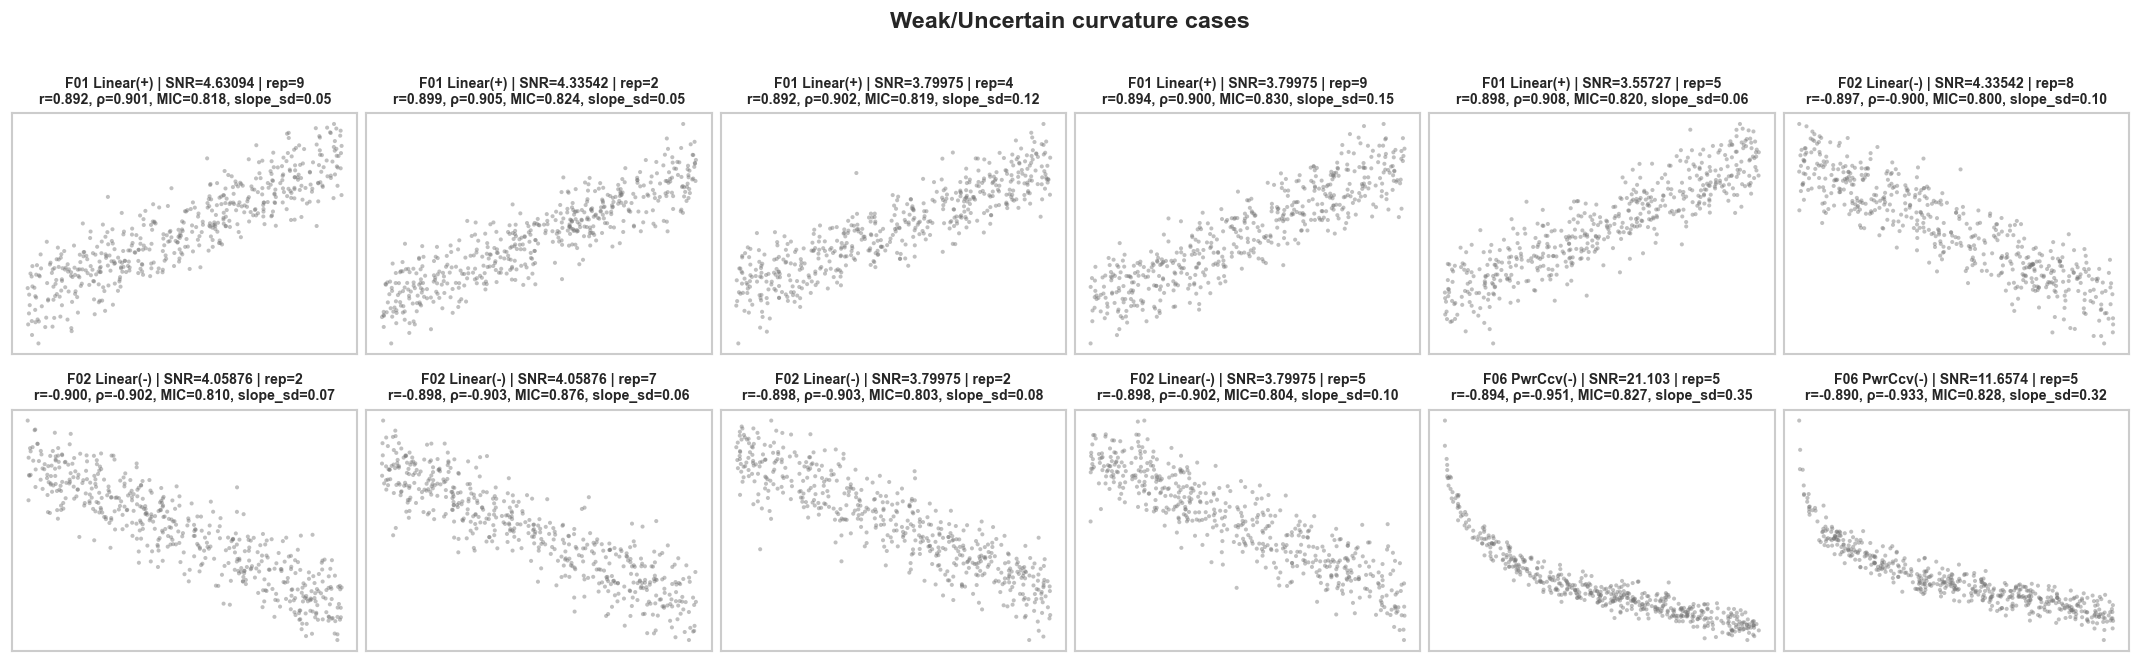

In [904]:
# ── Step 6 diagnostics: visualize Weak/Uncertain curvature cases ──
weak_cases = simple_cases[simple_cases['shape_tree'] == 'Weak/Uncertain'].copy()
weak_cases = weak_cases.sort_values(['family_id', 'snr_val', 'replicate', 'case_id'], ascending=[True, False, True, True])

print(f'Weak/Uncertain cases: {len(weak_cases):,}')
if len(weak_cases) > 0:
    weak_pts = np.load(S1_DIR / 'scatter_points.npz')
    weak_x_all, weak_y_all = weak_pts['x'], weak_pts['y']
    weak_case_idx = pd.Series(np.arange(len(cases)), index=cases['case_id']).to_dict()

    ncols = min(6, len(weak_cases))
    nrows = math.ceil(len(weak_cases) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.0 * ncols, 2.75 * nrows), squeeze=False)
    axes_flat = axes.ravel()

    for ax, (_, row) in zip(axes_flat, weak_cases.iterrows()):
        idx = weak_case_idx.get(row['case_id'])
        if idx is None:
            ax.set_visible(False)
            continue

        ax.scatter(weak_x_all[idx], weak_y_all[idx], s=6, alpha=0.45,
                   color=C_WEAK, edgecolors='none')
        snr_label = '∞' if row['snr_val'] == float('inf') else f'{row["snr_val"]:g}'
        title_top = f'{row["family_id"]} {SHORT.get(row["family_id"], "")} | SNR={snr_label} | rep={int(row["replicate"])}'
        title_bottom = f'r={row["pearson_r"]:.3f}, ρ={row["spearman_rho"]:.3f}, MIC={row["MIC"]:.3f}, slope_sd={row["slope_sd"]:.2f}'
        ax.set_title(title_top + chr(10) + title_bottom, fontsize=8.5, fontweight='bold')
        ax.set_xticks([])
        ax.set_yticks([])

    for ax in axes_flat[len(weak_cases):]:
        ax.set_visible(False)

    fig.suptitle('Weak/Uncertain curvature cases', fontsize=14, fontweight='bold', y=1.002)
    plt.tight_layout(h_pad=0.9, w_pad=0.45)
    plt.show()

## Classification Summary

Per-family tree profile across all cases.

In [905]:
# ── Classification Summary ──
S3_DIR = Path('output/S3')
S3_DIR.mkdir(parents=True, exist_ok=True)

def _cp(count, total):
    pct = count / total * 100 if total > 0 else 0
    return f'{count}({pct:.1f}%)'

summary_rows = []
for fid in all_fids:
    n_total = len(signal[signal['family_id'] == fid])
    filt_sub = filtered_cases[filtered_cases['family_id'] == fid] if fid in qual_fids else pd.DataFrame()
    n_global = len(filt_sub)

    fid_simple = simple_cases[simple_cases['family_id'] == fid]
    n_simple = len(fid_simple)
    fid_complex = complex_cases[complex_cases['family_id'] == fid] if fid in qual_fids else pd.DataFrame()
    n_complex = len(fid_complex)

    row = {
        'family_id': fid,
        'family_name': SHORT[fid],
        'n_total': n_total,
        'global': _cp(n_global, n_total),
        'simple': _cp(n_simple, n_total),
        'complex': _cp(n_complex, n_total),
    }

    if n_simple > 0:
        n_pos = int((fid_simple['direction_tree'] == 'Positive').sum())
        n_neg = int((fid_simple['direction_tree'] == 'Negative').sum())
        dir_maj = 'Positive' if n_pos >= n_neg else 'Negative'
        n_dir_maj = max(n_pos, n_neg)

        mono_maj = fid_simple['monotonicity_tree'].mode().iloc[0]
        n_mono_maj = int((fid_simple['monotonicity_tree'] == mono_maj).sum())

        n_line = int(fid_simple['is_line'].sum())

        shape_maj = fid_simple['shape_tree'].mode().iloc[0]
        n_shape_maj = int((fid_simple['shape_tree'] == shape_maj).sum())

        profile = f'Simple, {dir_maj}, {mono_maj} monotonicity, {shape_maj}'

        row.update({
            'direction': dir_maj,
            'direction_maj': _cp(n_dir_maj, n_total),
            'monotonicity': mono_maj,
            'mono_maj': _cp(n_mono_maj, n_total),
            'line': _cp(n_line, n_total),
            'shape': shape_maj,
            'shape_maj': _cp(n_shape_maj, n_total),
            'profile': profile,
        })
    elif n_global > 0:
        row.update({
            'direction': '—', 'direction_maj': '—',
            'monotonicity': '—', 'mono_maj': '—',
            'line': '—',
            'shape': '—', 'shape_maj': '—',
            'profile': 'Complex',
        })
    else:
        row.update({
            'direction': '—', 'direction_maj': '—',
            'monotonicity': '—', 'mono_maj': '—',
            'line': '—',
            'shape': '—', 'shape_maj': '—',
            'profile': 'No global relationship',
        })

    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)

csv_path = S3_DIR / 'classification_summary.csv'
summary_df.to_csv(csv_path, index=False)

print(f'═══ Classification Summary  (denominator = n_total per family) ═══')
print(f'Variant levels: {[l for l in ["strong","standard","mild"] if l in filtered_cases["variant_level"].values]}')
print(f'Filter: MIC ≥ {MIC_THRESH}, dcor ≥ {DCOR_THRESH}')
print(f'Filtered: {len(filtered_cases):,} / {len(signal):,}  ({len(filtered_cases)/len(signal):.1%})')
print(f'Simple:   {len(simple_cases):,} / {len(filtered_cases):,}  ({len(simple_cases)/len(filtered_cases):.1%})')
print()

hdr = f'{"Family":<16} {"Global":>14} {"Simple":>14} {"Complex":>14} {"Dir(maj)":>16} {"Mono(maj)":>16} {"Shape(maj)":>16} {"n_total":>7}  {"Profile"}'
print(hdr)
print('─' * len(hdr))
for _, r in summary_df.iterrows():
    fid = r['family_id']
    nt = int(r['n_total'])
    if r.get('direction', '—') != '—' and r['direction'] != '—':
        dir_label = '+' if r['direction'] == 'Positive' else '−'
        print(f'{fid} {SHORT[fid]:<10} '
              f'{r["global"]:>14} '
              f'{r["simple"]:>14} '
              f'{r["complex"]:>14} '
              f'{dir_label} {r["direction_maj"]:>14} '
              f'{r["monotonicity"][:3]} {r["mono_maj"]:>12} '
              f'{r["shape_maj"]:>16} '
              f'{nt:>7,}  {r["profile"]}')
    elif r.get('profile', '') == 'Complex':
        print(f'{fid} {SHORT[fid]:<10} '
              f'{r["global"]:>14} '
              f'{"—":>14} '
              f'{r["complex"]:>14} '
              f'{"—":>16} {"—":>16} {"—":>16} '
              f'{nt:>7,}  {r["profile"]}')
    else:
        print(f'{fid} {SHORT[fid]:<10} '
              f'{r["global"]:>14} '
              f'{"—":>14} {"—":>14} '
              f'{"—":>16} {"—":>16} {"—":>16} '
              f'{nt:>7,}  {r["profile"]}')

print()
print(f'Saved to {csv_path}')

═══ Classification Summary  (denominator = n_total per family) ═══
Variant levels: ['strong']
Filter: MIC ≥ 0.8, dcor ≥ 0
Filtered: 11,629 / 52,000  (22.4%)
Simple:   9,290 / 11,629  (79.9%)

Family                   Global         Simple        Complex         Dir(maj)        Mono(maj)       Shape(maj) n_total  Profile
─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
F01 Linear(+)      707(35.4%)     707(35.4%)        0(0.0%) +     707(35.4%) Str   706(35.3%)       702(35.1%)   2,000  Simple, Positive, Strong monotonicity, Line
F02 Linear(-)      707(35.4%)     707(35.4%)        0(0.0%) −     707(35.4%) Str   707(35.4%)       702(35.1%)   2,000  Simple, Negative, Strong monotonicity, Line
F03 PwrCvx(+)      520(26.0%)     520(26.0%)        0(0.0%) +     520(26.0%) Str   370(18.5%)       520(26.0%)   2,000  Simple, Positive, Strong monotonicity, Convex
F04 PwrCvx(-)      517(25.9%)     517(25.9%)        0(

## SNR Breakdown — Shape Classification Rate by Noise Level

How does each family's dominant shape hold up as SNR decreases?

In [906]:
# # ── SNR Breakdown: shape classification by SNR ──
# simple_cases['snr_val'] = simple_cases['snr'].apply(
#     lambda x: float('inf') if str(x) == 'inf' else float(x))

# snr_levels = sorted(simple_cases['snr_val'].unique(), reverse=True)
# snr_labels = [f'{s:.0f}' if np.isfinite(s) else '∞' for s in snr_levels]

# all_shapes = ['Line', 'Convex', 'Concave', 'Inflected', 'Weak/Uncertain']

# print(f'═══ Shape Proportion by SNR ═══')
# print()

# hdr_parts = [f'{"Family":<16}'] + [f'{sl:>8}' for sl in snr_labels]
# hdr = ''.join(hdr_parts)
# print(hdr)
# print('─' * len(hdr))

# for fid in simple_fids:
#     fid_data = simple_cases[simple_cases['family_id'] == fid]
#     parts = [f'{fid} {SHORT[fid]:<10}']
#     for sv in snr_levels:
#         sub = fid_data[fid_data['snr_val'] == sv]
#         n = len(sub)
#         if n == 0:
#             parts.append(f'{"—":>8}')
#         else:
#             maj = sub['shape_tree'].mode().iloc[0]
#             n_maj = int((sub['shape_tree'] == maj).sum())
#             parts.append(f'{maj[:4]:>4}{n_maj/n:>4.0%}')
#     print(''.join(parts))